# NYC Yellow Taxi - Operational Analysis 2024

This project examines recorded yellow taxi trips: when they take place, where they start and their recorded amounts. The analysis is descriptive. Completed trips measure observed activity; they do not capture unmet demand or trips that never took place.

Data preparation is in `src/etl.py`. This notebook reads the processed outputs to separate cleaning from interpretation.

**Report status:** the editable Power BI report is being standardized to English. Its previous version passed numerical and PDF visual checks. A new Desktop export is required to verify the translated presentation; actual click interactions remain unconfirmed.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
DATA = ROOT / "data/processed"
required = ["taxi_fact_2024.parquet", "taxi_hourly_system_2024.csv", "cleaning_audit_2024.csv", "validation_summary.json"]
missing = [name for name in required if not (DATA / name).exists()]
if missing:
    raise FileNotFoundError(f"Missing {missing}. Run python src/etl.py from the project root first.")
fact = pd.read_parquet(DATA / "taxi_fact_2024.parquet")
hourly = pd.read_csv(DATA / "taxi_hourly_system_2024.csv", parse_dates=["pickup_hour"])
# Translate display categories in memory; preserve the reviewed source files.
precipitation_labels = {'Sin precipitación': 'No precipitation', 'Traza': 'Trace', 'Ligera': 'Light', 'Moderada': 'Moderate', 'Intensa': 'Heavy', 'Desconocida': 'Unknown'}
hourly["precipitation_category"] = hourly["precipitation_category"].replace(precipitation_labels)
audit = pd.read_csv(DATA / "cleaning_audit_2024.csv")
quality = pd.read_csv(DATA / "source_quality_2024.csv")
validation = json.loads((DATA / "validation_summary.json").read_text())
FIGURES = ROOT / "images/analysis"
FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 12)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.figsize": (10, 4.8), "axes.spines.top": False,
                    "axes.spines.right": False, "axes.titleweight": "bold", "font.size": 10})
BLUE, ORANGE = "#245A72", "#D28A44"

def save_chart(name):
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()

assert int(fact.trip_count.sum()) == validation["clean_trips"]
assert int(hourly.trip_count.sum()) == validation["clean_trips"]
assert int(quality.raw_trips.sum()) == int(audit.rows_removed.sum() + fact.trip_count.sum())
np.testing.assert_allclose(fact.total_revenue.sum(), hourly.total_revenue.sum(), rtol=0, atol=.01)
assert not fact.duplicated(["pickup_hour", "PULocationID", "airport_trip_share"]).any()
print("Aggregate totals and keys verified.")

## 1. Data quality

The original cleaning rules are retained: pickups in 2024; positive location IDs; distance up to 100 miles; fare and total amount up to $500; and recorded duration up to 180 minutes. All lower bounds are strictly greater than zero. These are analytical cleaning choices, not legal limits or proof that every remaining record is accurate.

Exclusions are counted **sequentially**: a row that fails several rules is counted only under its first exclusion. A valid 2024 trip remains eligible even if it appears in another month's source file. No deduplication is claimed because the source provides no reliable unique trip key.


In [2]:
cleaning = audit.groupby("rule", sort=False)[["rows_removed"]].sum()
display(cleaning.rename(columns={"rows_removed": "Excluded rows"}))
print(f"Source records: {quality.raw_trips.sum():,}")
print(f"Retained records: {fact.trip_count.sum():,}")
print(f"Valid trips outside their source-file month: {quality.valid_trips_outside_source_month.sum():,}")
print(f"Missing Airport_fee values: {quality.airport_fee_missing_count.sum():,}")

,Excluded rows
rule,
pickup_in_2024,56
positive_location_ids,0
distance_0_to_100_miles,777918
fare_0_to_500_usd,686900
total_0_to_500_usd,160
duration_0_to_180_minutes,26808


## 2. Overview

Amounts refer to `total_amount`: recorded passenger charges, including recorded tips. They are labelled **recorded total amount**, not profit. Means divide additive sums by trip counts rather than averaging group means.


In [3]:
trips = int(fact.trip_count.sum())
revenue = fact.total_revenue.sum()
kpis = pd.Series({"Trips": trips, "Recorded total amount (USD)": revenue,
    "Mean recorded amount (USD)": revenue / trips,
    "Mean distance (miles)": fact.total_trip_distance.sum() / trips,
    "Mean recorded duration (min)": fact.total_trip_duration_min.sum() / trips,
    "Trips per real calendar hour": trips / hourly.elapsed_hours.sum()})
display(kpis.to_frame("Value"))

,Value
Trips,"39,677,878.00"
Recorded total amount (USD),"1,135,817,146.18"
Mean recorded amount (USD),28.63
Mean distance (miles),3.42
Mean recorded duration (min),16.91
Trips per real calendar hour,"4,517.06"


## 3. Activity by month, weekday and hour

Periods of different lengths are compared using trips per real hour. The calendar counts 23 hours on the March clock-change day and 25 in November. The repeated autumn hour remains one clock-hour label in the taxi data, with two hours of exposure.


,trips,hours,amount_usd,trips_per_hour,mean_amount_usd
pickup_month,,,,,
1,"2,867,575.00",744,"78,378,845.58","3,854.27",27.33
2,"2,899,445.00",696,"78,942,043.17","4,165.87",27.23
3,"3,437,610.00",743,"95,743,331.05","4,626.66",27.85
4,"3,411,742.00",720,"96,141,248.41","4,738.53",28.18
5,"3,613,931.00",744,"104,775,458.55","4,857.43",28.99
6,"3,425,722.00",720,"98,235,743.99","4,757.95",28.68
7,"2,971,627.00",744,"86,060,068.22","3,994.12",28.96
8,"2,865,066.00",744,"83,672,508.22","3,850.90",29.20
9,"3,481,619.00",720,"102,620,823.98","4,835.58",29.48


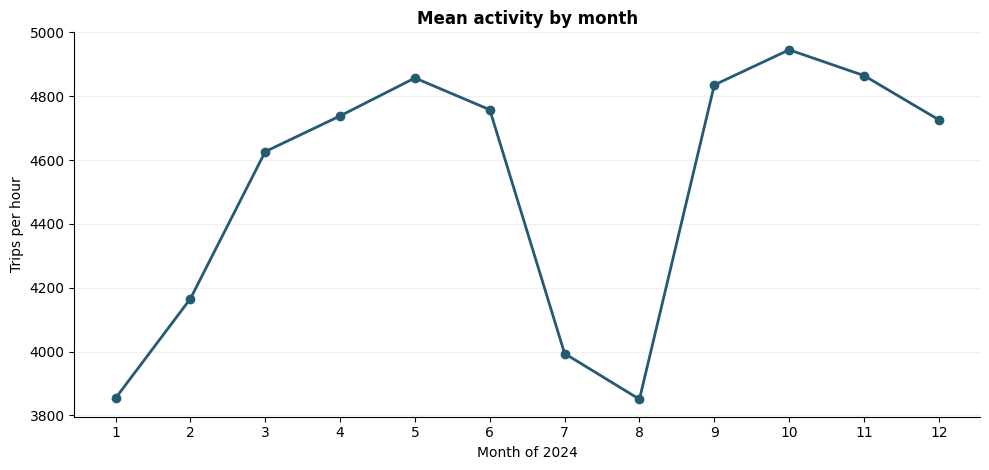

In [4]:
monthly = hourly.groupby("pickup_month").agg(trips=("trip_count", "sum"), hours=("elapsed_hours", "sum"), amount_usd=("total_revenue", "sum"))
monthly["trips_per_hour"] = monthly.trips / monthly.hours
monthly["mean_amount_usd"] = monthly.amount_usd / monthly.trips
display(monthly)
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.trips_per_hour, marker="o", color=BLUE, linewidth=2)
ax.set(xticks=range(1, 13), xlabel="Month of 2024", ylabel="Trips per hour", title="Mean activity by month")
ax.grid(axis="y", alpha=.18)
save_chart("01_monthly_demand")

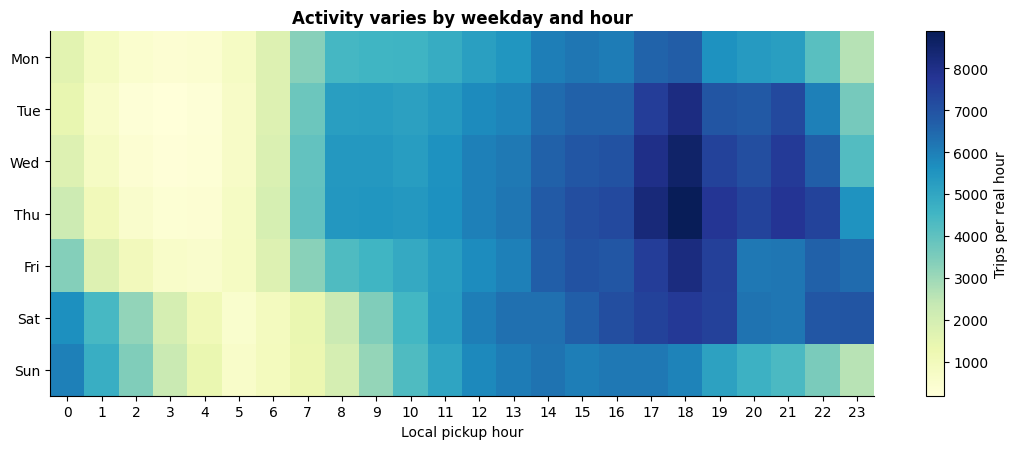

In [5]:
grid = hourly.groupby(["pickup_dayofweek", "pickup_hour_num"]).agg(trips=("trip_count", "sum"), hours=("elapsed_hours", "sum"))
grid["trips_per_hour"] = grid.trips / grid.hours
heatmap = grid.trips_per_hour.unstack()
fig, ax = plt.subplots(figsize=(11, 4.6))
im = ax.imshow(heatmap, cmap="YlGnBu", aspect="auto")
ax.set(xticks=range(24), yticks=range(7), yticklabels=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], xlabel="Local pickup hour", title="Activity varies by weekday and hour")
fig.colorbar(im, ax=ax, label="Trips per real hour")
save_chart("02_weekday_hour")
by_hour = hourly.groupby("pickup_hour_num").agg(trips=("trip_count", "sum"), hours=("elapsed_hours", "sum"))
by_hour["trips_per_hour"] = by_hour.trips / by_hour.hours
print(f"Month with highest hourly activity: {monthly.trips_per_hour.idxmax()}; lowest: {monthly.trips_per_hour.idxmin()}.")
print(f"Hour with highest mean activity: {by_hour.trips_per_hour.idxmax():02}:00.")

## 4. Geographic concentration

Zones describe pickup locations. A higher average recorded amount can reflect longer trips, surcharges and tolls. It does not establish higher margins or driver productivity.


In [6]:
borough = fact.groupby("pickup_borough_grouped").agg(trips=("trip_count", "sum"), amount_usd=("total_revenue", "sum"))
borough["trip_share_pct"] = 100 * borough.trips / trips
borough["amount_share_pct"] = 100 * borough.amount_usd / revenue
borough["mean_amount_usd"] = borough.amount_usd / borough.trips
display(borough.sort_values("trips", ascending=False))
zones = fact.groupby(["PULocationID", "pickup_zone", "pickup_borough_grouped"], as_index=False).agg(trips=("trip_count", "sum"), amount_usd=("total_revenue", "sum"))
zones["mean_amount_usd"] = zones.amount_usd / zones.trips
top = zones.nlargest(10, "trips")
print(f"The ten busiest zones account for {100*top.trips.sum()/trips:.1f}% of trips and {100*top.amount_usd.sum()/revenue:.1f}% of recorded amounts.")
display(top[["pickup_zone", "trips", "mean_amount_usd"]])

,trips,amount_usd,trip_share_pct,amount_share_pct,mean_amount_usd
pickup_borough_grouped,,,,,
Manhattan,35241154,"843,199,971.13",88.82,74.24,23.93
Queens,3644095,"266,588,820.43",9.18,23.47,73.16
Brooklyn,553762,"17,617,522.42",1.40,1.55,31.81
Unknown,122470,"4,159,508.70",0.31,0.37,33.96
Bronx,113697,"4,069,163.26",0.29,0.36,35.79
Staten Island,1462,"65,436.80",0.00,0.01,44.76
Newark,1238,"116,723.44",0.00,0.01,94.28


,pickup_zone,trips,mean_amount_usd
234,Upper East Side South,1871207,20.74
129,JFK Airport,1868777,82.66
158,Midtown Center,1860850,25.25
233,Upper East Side North,1690851,21.13
159,Midtown East,1380993,24.58
227,Times Sq/Theatre District,1337651,28.99
183,Penn Station/Madison Sq West,1323747,25.58
139,Lincoln Square East,1280779,22.35
135,LaGuardia Airport,1260300,68.54
167,Murray Hill,1139663,24.34


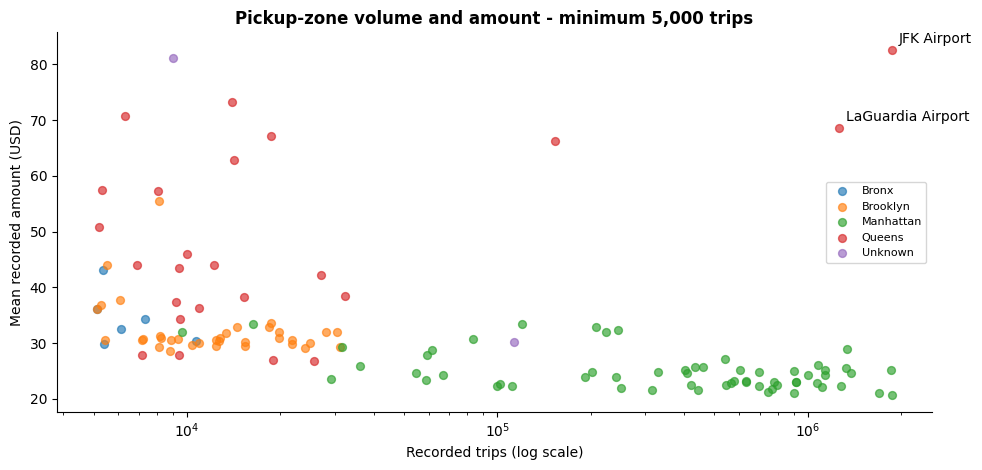

In [7]:
MIN_TRIPS = 5000
eligible = zones.loc[zones.trips.ge(MIN_TRIPS)]
fig, ax = plt.subplots()
for name, group in eligible.groupby("pickup_borough_grouped"):
    ax.scatter(group.trips, group.mean_amount_usd, label=name, alpha=.65, s=32)
for _, row in eligible.loc[eligible.PULocationID.isin([132, 138])].iterrows():
    ax.annotate(row.pickup_zone, (row.trips, row.mean_amount_usd), xytext=(5, 5), textcoords="offset points")
ax.set_xscale("log")
ax.set(xlabel="Recorded trips (log scale)", ylabel="Mean recorded amount (USD)", title="Pickup-zone volume and amount - minimum 5,000 trips")
ax.legend(fontsize=8)
save_chart("03_zone_volume_value")

## 5. Airports: two separate definitions

- **Positive recorded airport fee:** `Airport_fee > 0`; TLC defines this field for JFK and LaGuardia pickups.
- **Airport-zone pickup:** `PULocationID` is 1 (Newark), 132 (JFK) or 138 (LaGuardia).

Neither definition identifies all trips to or from airports. Missing `Airport_fee` values are counted separately; the complementary segment means "no positive recorded fee". Each hour-zone group is split by the positive-fee indicator before aggregation.


,trips,amount_usd,distance_miles,duration_min,mean_amount_usd,trip_share_pct,amount_share_pct
No positive recorded fee,36514778,"894,122,496.38","93,892,376.69","549,758,272.50",24.49,92.03,78.72
Positive recorded fee,3163100,"241,694,649.80","41,859,444.28","121,309,706.30",76.41,7.97,21.28


,No positive recorded fee,Positive recorded fee
Outside airport zone,36411174,136389
Airport-zone pickup,103604,3026711


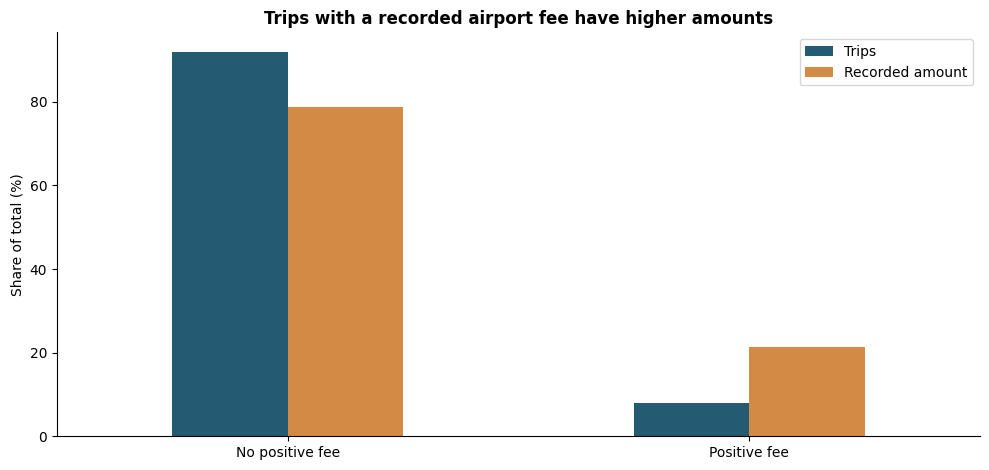

In [8]:
airport = fact.groupby("airport_trip_share").agg(trips=("trip_count", "sum"), amount_usd=("total_revenue", "sum"), distance_miles=("total_trip_distance", "sum"), duration_min=("total_trip_duration_min", "sum"))
airport["mean_amount_usd"] = airport.amount_usd / airport.trips
airport["trip_share_pct"] = 100 * airport.trips / trips
airport["amount_share_pct"] = 100 * airport.amount_usd / revenue
airport.index = ["No positive recorded fee", "Positive recorded fee"]
display(airport)
reconciliation = fact.groupby(["airport_pickup", "airport_trip_share"])["trip_count"].sum().unstack(fill_value=0)
reconciliation.index = ["Outside airport zone", "Airport-zone pickup"]
reconciliation.columns = ["No positive recorded fee", "Positive recorded fee"]
assert int(reconciliation.to_numpy().sum()) == trips
display(reconciliation)
fig, ax = plt.subplots()
airport[["trip_share_pct", "amount_share_pct"]].plot.bar(ax=ax, color=[BLUE, ORANGE], rot=0)
ax.set(ylabel="Share of total (%)", xlabel="", title="Trips with a recorded airport fee have higher amounts")
ax.set_xticklabels(["No positive fee", "Positive fee"])
ax.legend(["Trips", "Recorded amount"])
save_chart("04_airport_share")

In [9]:
airport_hour = hourly.groupby("pickup_hour_num").agg(trips=("trip_count", "sum"), airport_fee_trips=("airport_surcharge_trip_count", "sum"), amount_usd=("total_revenue", "sum"), airport_fee_amount_usd=("airport_surcharge_total_revenue", "sum"))
airport_hour["airport_fee_trip_share_pct"] = 100 * airport_hour.airport_fee_trips / airport_hour.trips
airport_hour["airport_fee_amount_share_pct"] = 100 * airport_hour.airport_fee_amount_usd / airport_hour.amount_usd
display(airport_hour[["airport_fee_trip_share_pct", "airport_fee_amount_share_pct"]].loc[[4, 12, 18, 23]])

,airport_fee_trip_share_pct,airport_fee_amount_share_pct
pickup_hour_num,,
4,2.73,5.68
12,6.92,18.85
18,7.13,19.77
23,11.67,28.20


## 6. Weather as context

The weather source is Central Park station USW00094728, with precipitation already expressed in millimetres. One routine `FM-15` report per UTC hour is used; overlapping `FM-16` special reports are not treated as additional hours. Precipitation covers the preceding hour, usually ending at :51, so assignment to a clock-hour group is approximate.

`T` is a trace, kept separate from zero. Missing observations remain unknown. UTC timestamps in METAR remarks allow ten inconsistent `DATE` labels near clock changes to be corrected before conversion to New York time. The repeated autumn hour is excluded from weather comparisons because its two occurrences cannot be separated in the aggregated taxi records.

The categories (light below 2.5 mm, moderate 2.5 to below 10 mm, heavy at least 10 mm) are project-defined descriptive bands. These comparisons **do not adjust for** month, weekday, hour, holidays or taxi supply and do not estimate a precipitation effect.


,hours,trips,amount_usd,trips_per_hour,mean_amount_usd
precipitation_category,,,,,
No precipitation,7568,"34,070,088.00","978,300,882.52","4,501.86",28.71
Trace,434,"2,006,959.00","56,547,366.32","4,624.33",28.18
Light,573,"2,576,120.00","72,479,766.42","4,495.85",28.14
Moderate,110,"602,520.00","16,302,487.60","5,477.45",27.06
Heavy,17,"108,946.00","2,866,039.38","6,408.59",26.31
Unknown,82,"313,245.00","9,320,603.94","3,820.06",29.75


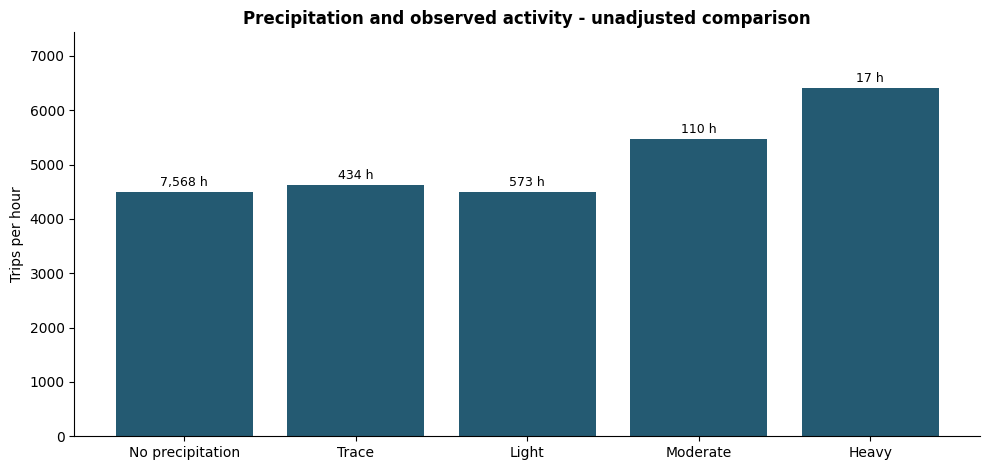

In [10]:
order = ["No precipitation", "Trace", "Light", "Moderate", "Heavy", "Unknown"]
weather = hourly.loc[hourly.elapsed_hours.gt(0)].groupby("precipitation_category").agg(hours=("elapsed_hours", "sum"), trips=("trip_count", "sum"), amount_usd=("total_revenue", "sum")).reindex(order)
weather["trips_per_hour"] = weather.trips / weather.hours
weather["mean_amount_usd"] = weather.amount_usd / weather.trips
display(weather)
known_weather = weather.drop(index="Unknown")
fig, ax = plt.subplots()
ax.bar(known_weather.index, known_weather.trips_per_hour, color=BLUE)
for i, row in enumerate(known_weather.itertuples()):
    ax.annotate(f"{int(row.hours):,} h", (i, row.trips_per_hour), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)
ax.margins(y=.16)
ax.set(ylabel="Trips per hour", title="Precipitation and observed activity - unadjusted comparison")
save_chart("05_weather_context")
print(f"The heavy-precipitation group contains only {int(weather.loc['Heavy','hours'])} hours: exploratory interpretation only.")

### Light and the calendar

Daylight/darkness compares each hour's midpoint with sunrise and sunset in the same time reference. The averages describe different periods; they cannot establish that darkness causes more or less activity. The earlier claim of "independent explanatory value" is removed because the normalization did not support it.


In [11]:
light = hourly.loc[hourly.is_dark.notna() & hourly.elapsed_hours.eq(1)].groupby("is_dark").agg(hours=("elapsed_hours", "sum"), trips=("trip_count", "sum"), amount_usd=("total_revenue", "sum"))
light["trips_per_hour"] = light.trips / light.hours
light["mean_amount_usd"] = light.amount_usd / light.trips
light.index = ["Daylight", "Darkness"]
display(light)
daily = hourly.groupby(hourly.pickup_hour.dt.date).agg(trips=("trip_count", "sum"), hours=("elapsed_hours", "sum"))
daily["trips_per_hour"] = daily.trips / daily.hours
print("Days with lowest hourly activity:")
display(daily.nsmallest(5, "trips_per_hour"))
print("Days with highest hourly activity:")
display(daily.nlargest(5, "trips_per_hour"))

,hours,trips,amount_usd,trips_per_hour,mean_amount_usd
Daylight,4471,"24,171,078.00","694,236,279.66","5,406.19",28.72
Darkness,4311,"15,498,323.00","441,389,356.68","3,595.06",28.48


,trips,hours,trips_per_hour
pickup_hour,,,
2024-12-25,"52,227.00",24,"2,176.12"
2024-07-04,"59,369.00",24,"2,473.71"
2024-01-07,"65,169.00",24,"2,715.38"
2024-02-13,"67,119.00",24,"2,796.62"
2024-05-27,"70,138.00",24,"2,922.42"


,trips,hours,trips_per_hour
pickup_hour,,,
2024-12-14,"154,170.00",24,"6,423.75"
2024-12-13,"152,796.00",24,"6,366.50"
2024-12-12,"150,895.00",24,"6,287.29"
2024-11-21,"146,880.00",24,"6,120.00"
2024-11-16,"145,155.00",24,"6,048.12"


## 7. Conclusions

Temporal patterns and geographic concentration provide the main story. Trips with a positive recorded airport fee account for a small share of trips and a larger share of recorded amounts. Weather provides supporting context, with coverage and group sizes shown explicitly.

Differences between airport pickup location and recorded fee are checks of data quality and business definitions. They are not resolved by inventing values or substituting one variable for the other.

## Limitations

- These are completed yellow taxi trips, not all mobility or unmet demand.
- Operating costs, vehicle availability and time without passengers are absent, so profitability and efficiency are not measured.
- Cash tips are unrecorded. `tip_rate` means the fraction of trips with a positive recorded tip, not a monetary tip percentage or general tipping propensity.
- Taxi timestamps do not distinguish the two occurrences of the autumn clock hour. Recorded duration can be inaccurate for trips crossing a clock change.
- One weather station cannot represent every zone. Precipitation can include the liquid equivalent of snow.
- Exclusions and missing values limit the population. Retained records are not claimed to be free of errors or duplicates.

Sources and decisions: [Methodology](docs/METHODOLOGY.md). Reconciliation evidence: [ETL totals](data/processed/validation_summary.json) and [independent SQL](data/processed/independent_validation.json).

**Extended analysis:** the airport-composition, calendar-adjusted monthly and morning/night zone comparisons are in [Analytical findings](docs/ANALYTICAL_FINDINGS.md). This notebook covers the underlying descriptive analysis. See the [Power BI guide](powerbi/IMPLEMENTATION.md) for setup and validation status.
